### 가설 1. 소비자는 평일보다 주말에 더 많이 구매할 것이다.

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import platform

# 시스템에 따라 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    # 맥 기본 한글 폰트
else:
    plt.rcParams['font.family'] = 'NanumGothic'     # 리눅스 또는 Google Colab 등

# 마이너스 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

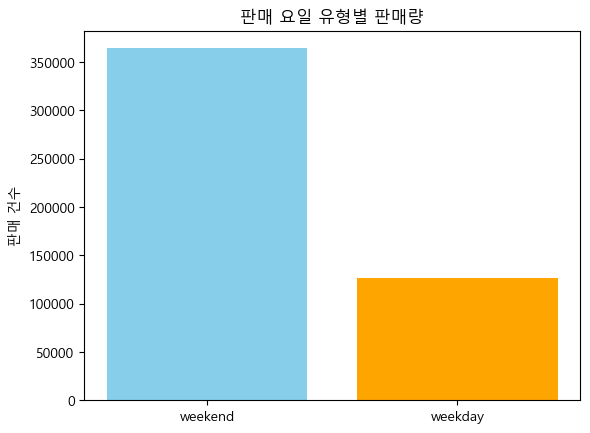

In [22]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

# 1. sold_at에서 요일 추출
df['sold_weekday'] = df['sold_at'].dt.weekday  # 0=월, ..., 6=일

# 2. 요일별 판매 건수 집계
sales_by_day = df['sold_weekday'].value_counts().sort_index()

# 3. 평일 vs 주말 구분
df['sold_day_type'] = df['sold_weekday'].apply(lambda x: 'weekday' if x < 5 else 'weekend')

# 4. 평일/주말별 판매량 집계
sales_by_type = df['sold_day_type'].value_counts()

# 5. 시각화 (선택)
import matplotlib.pyplot as plt

plt.bar(sales_by_type.index, sales_by_type.values, color=['skyblue', 'orange'])
plt.title('판매 요일 유형별 판매량')
plt.ylabel('판매 건수')
plt.show()

- 평일에 비해 주말의 판매량이 약 3배인 것을 확인할 수 있다.
- 소비자들의 소비습관이 주말에 몰려있는 것을 확인 가능하다.

### 가설 2. 리테일 가격이 비쌀수록 재고 회전율이 느리다

 피어슨 상관계수: 0.0007, p-value: 0.7606
 유의미한 선형 관계는 없습니다.


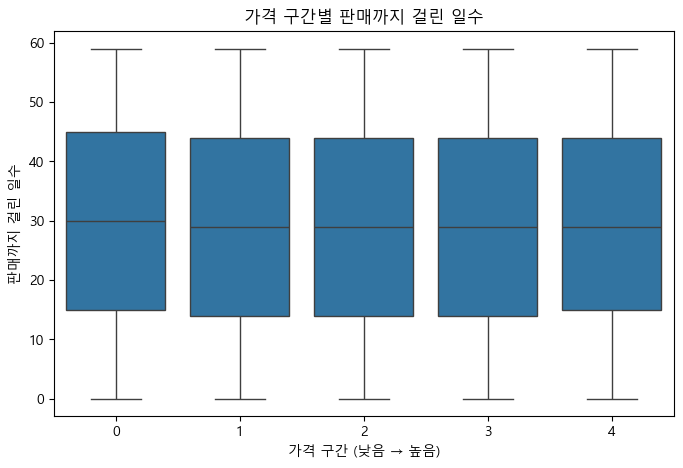

 ANOVA F-statistic: 1.2280, p-value: 0.2965
 가격 구간에 따른 평균 판매일의 유의미한 차이는 없습니다.


In [18]:
import seaborn as sns
from scipy.stats import pearsonr, f_oneway

# 날짜 데이터 변환 및 days_to_sell 계산
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['sold_at'] = pd.to_datetime(df['sold_at'], errors='coerce')
df['days_to_sell'] = (df['sold_at'] - df['created_at']).dt.days

# 결측치 제거
df_filtered = df[['product_retail_price', 'days_to_sell']].dropna()

# -------------------------------
#  1. 피어슨 상관계수 계산
# -------------------------------
corr, p_val = pearsonr(df_filtered['product_retail_price'], df_filtered['days_to_sell'])
print(f' 피어슨 상관계수: {corr:.4f}, p-value: {p_val:.4f}')
if p_val < 0.05:
    print(" 가격과 판매일수 간에 유의미한 선형 관계가 있습니다.")
else:
    print(" 유의미한 선형 관계는 없습니다.")

# -------------------------------
#  2. 가격 구간별 평균 판매일 차이 (Boxplot + ANOVA)
# -------------------------------
# 가격을 5구간으로 나눔 (구간 수는 조정 가능)
df_filtered['price_bin'] = pd.qcut(df_filtered['product_retail_price'], q=5, labels=False)

# boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='price_bin', y='days_to_sell', data=df_filtered)
plt.title('가격 구간별 판매까지 걸린 일수')
plt.xlabel('가격 구간 (낮음 → 높음)')
plt.ylabel('판매까지 걸린 일수')
plt.show()

# ANOVA 테스트
groups = [group['days_to_sell'].values for name, group in df_filtered.groupby('price_bin')]
f_stat, p_anova = f_oneway(*groups)
print(f' ANOVA F-statistic: {f_stat:.4f}, p-value: {p_anova:.4f}')
if p_anova < 0.05:
    print(" 가격 구간에 따라 평균 판매일에 유의미한 차이가 있습니다.")
else:
    print(" 가격 구간에 따른 평균 판매일의 유의미한 차이는 없습니다.")

- 제품의 리테일 가격과 재고 회전율 간에는 통계적으로 유의한 차이가 없다.
- 즉, 비싸다고 더 느리게 팔리는 것은 아니다.

### 가설 3. 마진율이 높을수록 오히려 판매 속도가 느릴 수 있다.

 피어슨 상관계수: -0.0005, p-value: 0.8371
→ 유의미한 상관관계는 없습니다.


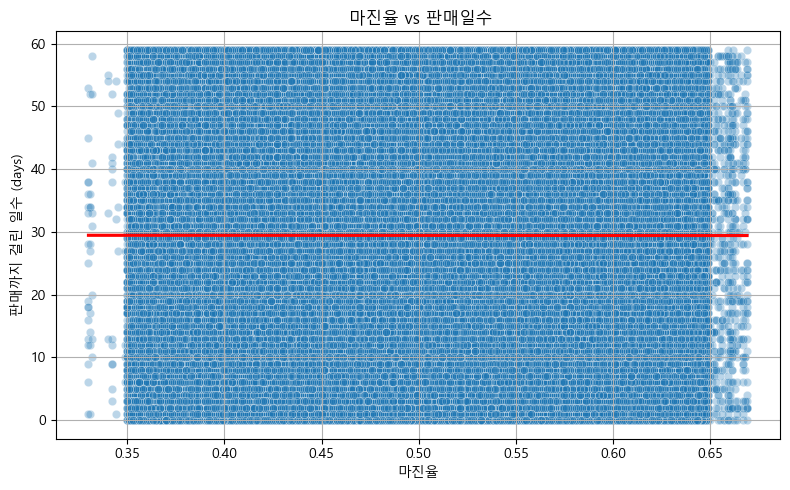

In [28]:
# 데이터 로드
df = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv")

# 날짜형으로 변환
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['sold_at'] = pd.to_datetime(df['sold_at'], errors='coerce')

# 판매일 계산
df['days_to_sell'] = (df['sold_at'] - df['created_at']).dt.days

# 마진율 계산 (단, 가격이 0인 경우는 제거)
df = df[(df['product_retail_price'] > 0) & (df['cost'] >= 0)]
df['margin_rate'] = (df['product_retail_price'] - df['cost']) / df['product_retail_price']

# 필요한 컬럼 필터링
df_filtered = df[['margin_rate', 'days_to_sell']].dropna()

# 피어슨 상관계수
corr, p_val = pearsonr(df_filtered['margin_rate'], df_filtered['days_to_sell'])

print(f' 피어슨 상관계수: {corr:.4f}, p-value: {p_val:.4f}')
if p_val < 0.05:
    print("→ 유의미한 상관관계가 있습니다.")
else:
    print("→ 유의미한 상관관계는 없습니다.")

# 시각화
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_filtered, x='margin_rate', y='days_to_sell', alpha=0.3)
sns.regplot(data=df_filtered, x='margin_rate', y='days_to_sell', scatter=False, color='red')
plt.title(' 마진율 vs 판매일수')
plt.xlabel('마진율')
plt.ylabel('판매까지 걸린 일수 (days)')
plt.grid(True)
plt.tight_layout()
plt.show()

- 검정결과 유의미한 상관관계는 없다는 것을 확인할 수 있었다.
- 시각화 결과 마진율과 판매일수가 큰 상관이 없다는 것을 확인할 수 있었다.

### 가설 4. 고가 상품은 특정 유통센터에서 더 빨리 판매된다.

   product_distribution_center_id       mean  count
1                               2  29.100302   4965
4                               5  29.118406   2559
9                              10  29.172927   2955
6                               7  29.434922   3442
2                               3  29.513963   5658
5                               6  29.595253   3118
0                               1  29.667681   3942
8                               9  29.676311   1659
7                               8  29.767408   4811
3                               4  30.188418   2314


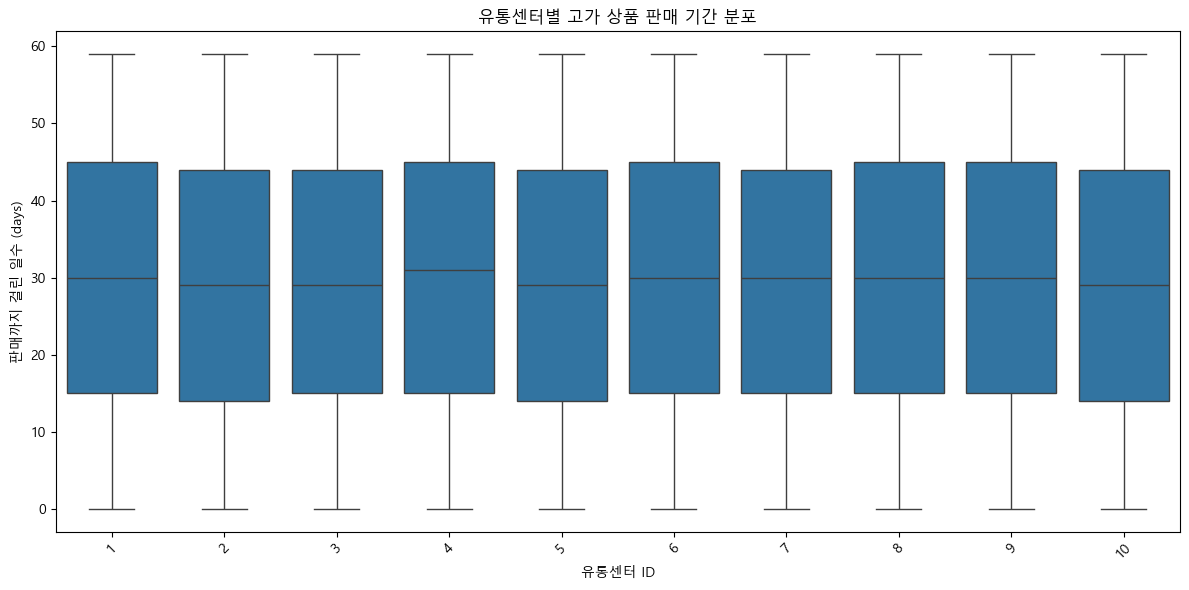

In [33]:
# 데이터 로드 및 날짜형 변환
df = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv")
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['sold_at'] = pd.to_datetime(df['sold_at'], errors='coerce')

# 판매 기간 계산
df['days_to_sell'] = (df['sold_at'] - df['created_at']).dt.days

# 고가 상품 기준 (상위 20%)
price_threshold = df['product_retail_price'].quantile(0.8)
high_price_df = df[df['product_retail_price'] >= price_threshold].copy()

# 필요한 컬럼 필터링 및 결측치 제거
high_price_df = high_price_df[['product_distribution_center_id', 'days_to_sell']].dropna()

# 유통센터별 평균 판매 기간 계산
center_stats = high_price_df.groupby('product_distribution_center_id')['days_to_sell'].agg(['mean', 'count']).reset_index()
center_stats = center_stats.sort_values(by='mean')

print(center_stats)

# 시각화: 유통센터별 고가 상품 판매 기간 분포
plt.figure(figsize=(12,6))
sns.boxplot(data=high_price_df, x='product_distribution_center_id', y='days_to_sell')
plt.xticks(rotation=45)
plt.title('유통센터별 고가 상품 판매 기간 분포')
plt.xlabel('유통센터 ID')
plt.ylabel('판매까지 걸린 일수 (days)')
plt.tight_layout()
plt.show()

- 유통센터별 고가 상품 평균 판매 기간은 약 29일에서 30일 사이로, 큰 차이는 없음.
- 센터 2번과 5번, 10번이 상대적으로 판매 기간이 좀 더 짧고 4번이 가장 긴 것으로 나타남

### 가설 5. SKU별 '입고 빈도'가 판매 기간에 영향을 미치는가?

피어슨 상관계수: 0.0035, p-value: 0.1422
→ 입고 빈도와 판매 기간 사이에 유의미한 상관관계는 없습니다.


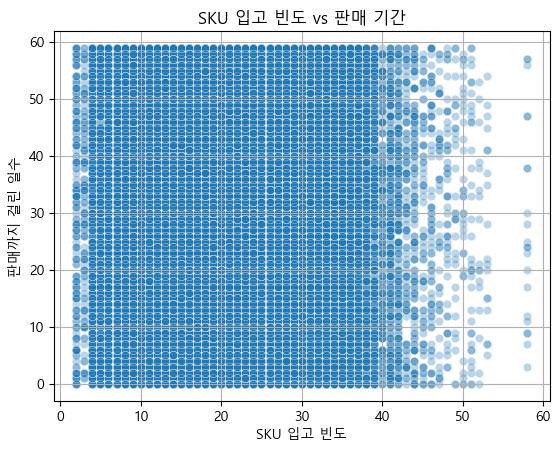

In [40]:
# 1. SKU별 입고 빈도 계산
sku_freq = df['product_sku'].value_counts()
df['sku_frequency'] = df['product_sku'].map(sku_freq)

# 2. 필요 열만 남기고 결측치 제거
df_freq = df[['sku_frequency', 'days_to_sell']].dropna()

# 3. 상관계수 분석
from scipy.stats import pearsonr

corr, p_val = pearsonr(df_freq['sku_frequency'], df_freq['days_to_sell'])
print(f"피어슨 상관계수: {corr:.4f}, p-value: {p_val:.4f}")

if p_val < 0.05:
    print("→ 입고 빈도와 판매 기간 사이에 유의미한 상관관계가 있습니다.")
else:
    print("→ 입고 빈도와 판매 기간 사이에 유의미한 상관관계는 없습니다.")

# 4. 시각화
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='sku_frequency', y='days_to_sell', data=df_freq, alpha=0.3)
plt.title('SKU 입고 빈도 vs 판매 기간')
plt.xlabel('SKU 입고 빈도')
plt.ylabel('판매까지 걸린 일수')
plt.grid(True)
plt.show()

- 피어슨 상관계수 0.035로 많이 입고되었다고 해서 반드시 빨리 팔리는 것은 아니다

### 가설 6. 제품 카테고리에 따라 평균적인 판매 기간의 차이가 존재할 것이다.

                                    mean        std  count
product_category                                          
Sleep & Lounge                 29.098546  17.209291  10726
Fashion Hoodies & Sweatshirts  29.257264  17.290505  11599
Active                         29.327140  17.184053   8880
Tops & Tees                    29.388254  17.211253  11629
Intimates                      29.439787  17.359571  13120
Swim                           29.477032  17.329169  11146
Jeans                          29.479316  17.278471  12401
Sweaters                       29.508970  17.150614  10981
Shorts                         29.587892  17.435945  10786
Accessories                    29.837724  17.322875   9527


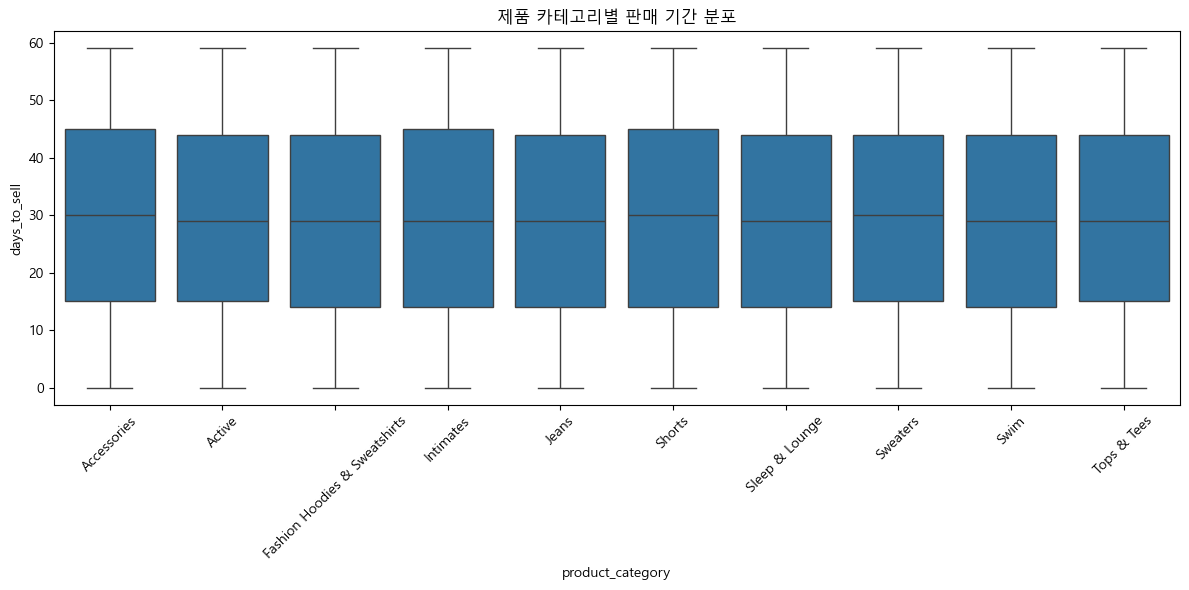


ANOVA F-statistic: 1.3436, p-value: 0.2082
→ 카테고리별 차이는 통계적으로 유의하지 않습니다. (H₀ 채택)


In [46]:
# 데이터 불러오기
df = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv", parse_dates=['created_at', 'sold_at'])

# 1. 날짜 형식으로 변환 (안전하게)
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['sold_at'] = pd.to_datetime(df['sold_at'], errors='coerce')

# 2. 판매 기간 계산
df['days_to_sell'] = (df['sold_at'] - df['created_at']).dt.days


# 결측값 제거
df_filtered = df[['product_category', 'days_to_sell']].dropna()

# 상위 N개 카테고리만 보기 (optional: 샘플 과다시)
top_n = 10
top_categories = df_filtered['product_category'].value_counts().head(top_n).index
df_top = df_filtered[df_filtered['product_category'].isin(top_categories)]

# 1. 카테고리별 통계 요약
print(df_top.groupby('product_category')['days_to_sell'].agg(['mean', 'std', 'count']).sort_values('mean'))

# 2. 시각화
plt.figure(figsize=(12, 6))
sns.boxplot(x='product_category', y='days_to_sell', data=df_top)
plt.xticks(rotation=45)
plt.title('제품 카테고리별 판매 기간 분포')
plt.tight_layout()
plt.show()

# 3. ANOVA
anova_data = [group['days_to_sell'].values for name, group in df_top.groupby('product_category')]
f_stat, p_val = f_oneway(*anova_data)
print(f"\nANOVA F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")

if p_val < 0.05:
    print("→ 카테고리에 따른 판매 기간의 유의미한 차이가 존재합니다. (H₀ 기각)")
else:
    print("→ 카테고리별 차이는 통계적으로 유의하지 않습니다. (H₀ 채택)")

In [48]:
from scipy.stats import f_oneway

# 카테고리별 판매일 리스트 모음
groups = [group['days_to_sell'].values for name, group in df_filtered.groupby('product_category')]

# ANOVA
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("→ 제품 카테고리에 따라 판매 기간의 유의미한 차이가 있습니다.")
else:
    print("→ 제품 카테고리에 따라 판매 기간의 유의미한 차이는 없습니다.")
    

ANOVA F-statistic: 0.9303, p-value: 0.5625
→ 제품 카테고리에 따라 판매 기간의 유의미한 차이는 없습니다.


### 가설 7. 입고 월이 판매 속도에 영향을 줄 것이다 (ㄱㅖ절성 여부)

                    mean        std  count
inbound_month                             
1.0            27.324141  18.201561  11785
2.0            29.893106  17.341651   9907
3.0            29.947305  17.403999  11576
4.0            30.099751  17.215223  12040
5.0            30.044919  17.366440  13313
6.0            30.113842  17.334709  13343
7.0            30.092108  17.308730  14939
8.0            30.077384  17.307794  16179
9.0            30.441558  17.212053  16632
10.0           30.476418  17.290598  19061
11.0           30.570588  17.207849  20733
12.0           24.310434  15.913126  17846
ANOVA F-statistic: 190.1114, p-value: 0.0000
→ 입고 월에 따라 판매 기간의 유의미한 차이가 있습니다 (계절성 존재 가능성)


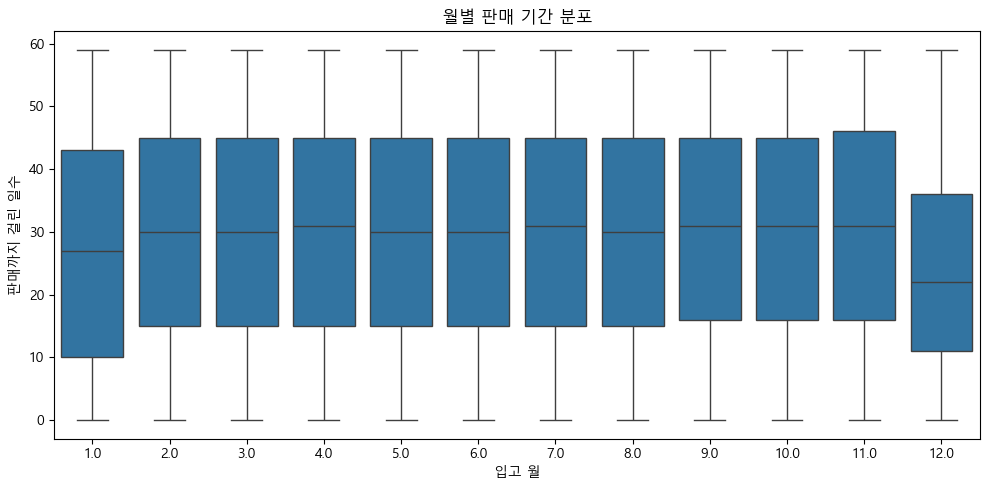

In [53]:
# 입고 월 추출
df['inbound_month'] = df['created_at'].dt.month

#월별 평균 판매 기간 요약
df_monthly = df[['inbound_month', 'days_to_sell']].dropna()
monthly_summary = df_monthly.groupby('inbound_month')['days_to_sell'].agg(['mean', 'std', 'count'])
print(monthly_summary)

#ANOVA검정
# 월별 그룹 리스트
groups = [group['days_to_sell'].values for _, group in df_monthly.groupby('inbound_month')]

# 일원분산분석
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("→ 입고 월에 따라 판매 기간의 유의미한 차이가 있습니다 (계절성 존재 가능성)")
else:
    print("→ 입고 월에 따른 판매 기간의 유의미한 차이는 없습니다")

#시각화
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_monthly, x='inbound_month', y='days_to_sell')
plt.title("월별 판매 기간 분포")
plt.xlabel("입고 월")
plt.ylabel("판매까지 걸린 일수")
plt.tight_layout()
plt.show()

- 12월/1월 : 연말 소비 증가 및 새해라는 특수상황에 따른 세일의 영향일 가능성
- 6월/11월 : 시즌 오프 제고 누적의 가능성  

                    sold_at                created_at  days_to_sell  \
0 2022-07-24 06:33:20+00:00 2022-07-02 07:09:20+00:00          21.0   
1                       NaT 2023-12-20 03:28:00+00:00           NaN   
2                       NaT 2023-06-04 02:53:00+00:00           NaN   
3 2021-11-22 02:19:52+00:00 2021-10-16 22:58:52+00:00          36.0   
4                       NaT 2021-08-07 16:33:00+00:00           NaN   

   inbound_month  
0            7.0  
1           12.0  
2            6.0  
3           10.0  
4            8.0  


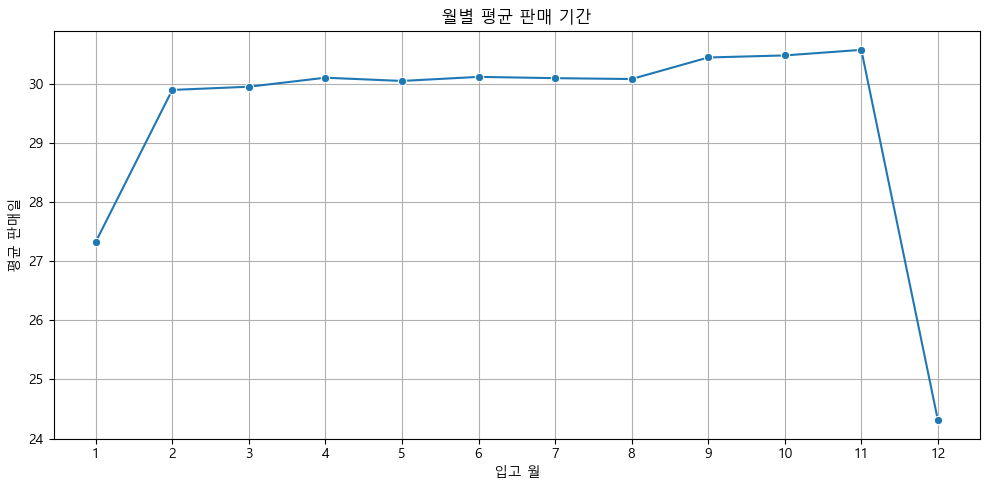

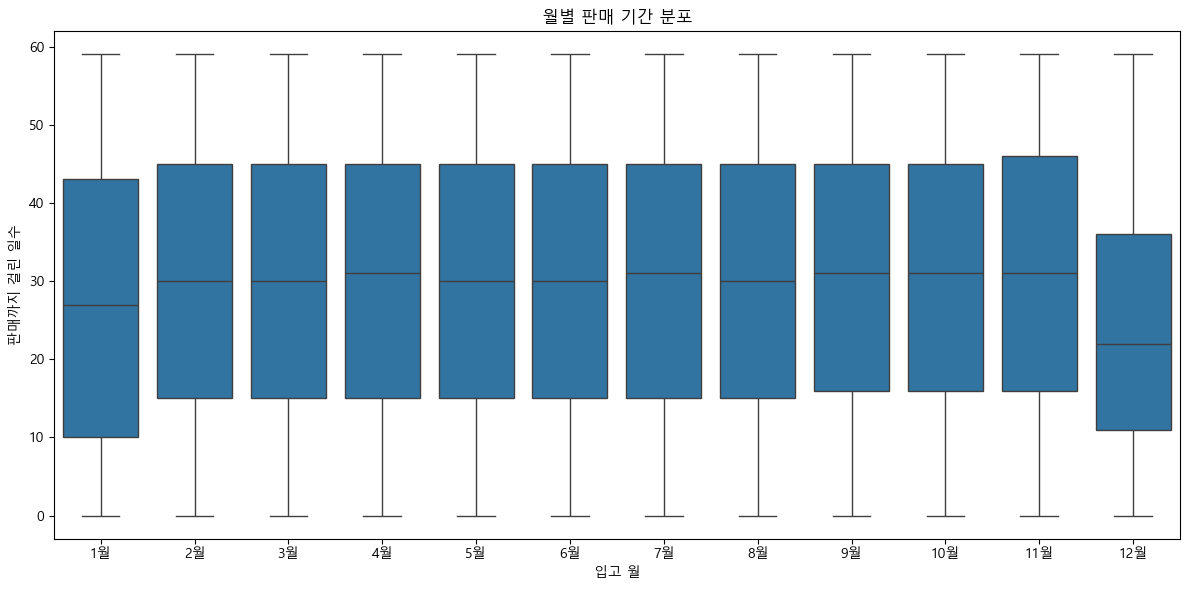

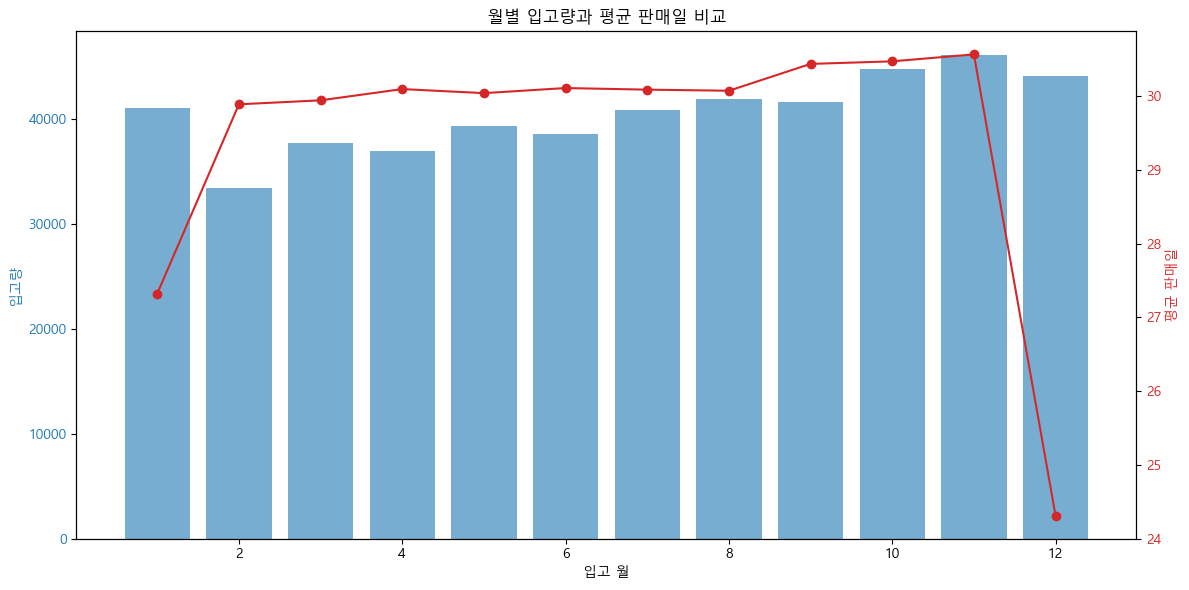

In [62]:
# 데이터 불러오기
# 1. 데이터 불러오기 (created_at, sold_at을 문자열로 읽음)
df = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv")

# 2. datetime 타입으로 변환 (타임존 정보 처리)
df['sold_at'] = pd.to_datetime(df['sold_at'], errors='coerce')
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# 3. tz-naive 와 tz-aware 문제 해결
# sold_at이 tz-naive면 UTC 타임존 부여
if df['sold_at'].dt.tz is None:
    df['sold_at'] = df['sold_at'].dt.tz_localize('UTC')

# created_at이 tz-naive면 UTC 타임존 부여
if df['created_at'].dt.tz is None:
    df['created_at'] = df['created_at'].dt.tz_localize('UTC')

# 4. 판매 기간 계산 (일 단위)
df['days_to_sell'] = (df['sold_at'] - df['created_at']).dt.days

# 5. 입고월 컬럼 생성
df['inbound_month'] = df['created_at'].dt.month

# 이후 원하는 분석 및 시각화 진행
print(df[['sold_at', 'created_at', 'days_to_sell', 'inbound_month']].head())

# 이후 계산
df['days_to_sell'] = (df['sold_at'] - df['created_at']).dt.days
df['inbound_month'] = df['created_at'].dt.month

# 1. 월별 평균 판매 기간 라인 차트
monthly_avg = df.groupby('inbound_month')['days_to_sell'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_avg, x='inbound_month', y='days_to_sell', marker='o')
plt.title('월별 평균 판매 기간')
plt.xlabel('입고 월')
plt.ylabel('평균 판매일')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. 월별 박스플롯 (판매 기간 분포 시각화)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='inbound_month', y='days_to_sell')
plt.title('월별 판매 기간 분포')
plt.xlabel('입고 월')
plt.ylabel('판매까지 걸린 일수')
plt.xticks(range(0, 12), [f'{i}월' for i in range(1, 13)])
plt.tight_layout()
plt.show()

# 3. 월별 입고량 vs 판매속도 비교 (입고량은 count, 판매속도는 평균)
monthly_stats = df.groupby('inbound_month').agg({'days_to_sell': 'mean', 'product_id': 'count'}).reset_index()
monthly_stats.rename(columns={'product_id': 'inbound_volume'}, inplace=True)

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('입고 월')
ax1.set_ylabel('입고량', color=color)
ax1.bar(monthly_stats['inbound_month'], monthly_stats['inbound_volume'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('평균 판매일', color=color)
ax2.plot(monthly_stats['inbound_month'], monthly_stats['days_to_sell'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('월별 입고량과 평균 판매일 비교')
fig.tight_layout()
plt.show()

### 가설 8. 상품 가격대별로 판매 기간의 차이는 있을 것이다.

ANOVA F-statistic: 0.9902, p-value: 0.6382
→ 제품 브랜드에 따른 판매 기간 차이가 통계적으로 유의하지 않습니다.


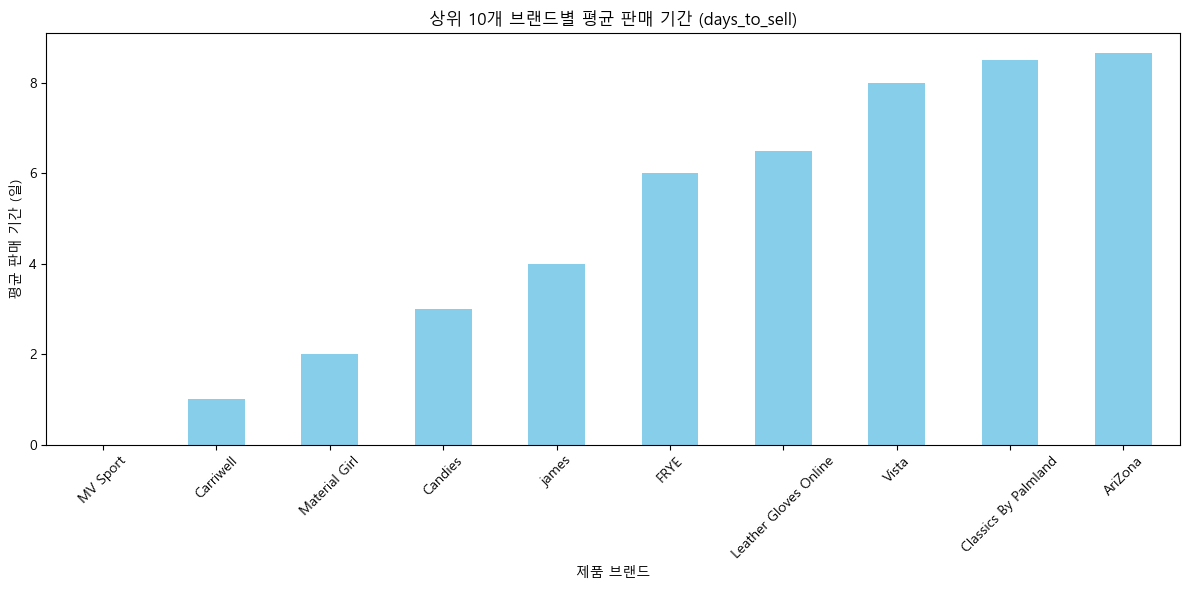

In [75]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv")

# 2. sold_at, created_at 컬럼을 datetime 타입으로 변환 (에러나면 NaT 처리)
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['sold_at'] = pd.to_datetime(df['sold_at'], errors='coerce')

# 3. datetime tz 정보 제거 (존재하면)
df['created_at'] = df['created_at'].dt.tz_localize(None)
df['sold_at'] = df['sold_at'].dt.tz_localize(None)

# 4. 판매 기간 계산 (days_to_sell)
df['days_to_sell'] = (df['sold_at'] - df['created_at']).dt.days

# 5. 결측치 제거 (필요한 컬럼)
df_clean = df[['product_brand', 'days_to_sell']].dropna()

# 6. 브랜드별 판매 기간 그룹 만들기
groups = [group['days_to_sell'].values for name, group in df_clean.groupby('product_brand')]

# 7. ANOVA 검정
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")
if p_val < 0.05:
    print("→ 제품 브랜드에 따른 판매 기간 차이가 통계적으로 유의합니다.")
else:
    print("→ 제품 브랜드에 따른 판매 기간 차이가 통계적으로 유의하지 않습니다.")

# 8. 브랜드별 평균 판매 기간 상위 10개만 시각화
brand_summary = df_clean.groupby('product_brand')['days_to_sell'].mean().sort_values().head(10)

plt.figure(figsize=(12,6))
brand_summary.plot(kind='bar', color='skyblue')
plt.title("상위 10개 브랜드별 평균 판매 기간 (days_to_sell)")
plt.ylabel("평균 판매 기간 (일)")
plt.xlabel("제품 브랜드")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()